In [2]:
# imports
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import json

plt.rcParams['figure.figsize'] = (14,4)

In [4]:
# loading file and inspecting
df = pd.read_csv('../data/NAB/data/realKnownCause/machine_temperature_system_failure.csv')
df['timestamp'] = pd.to_datetime(df['timestamp'])
df.set_index('timestamp', inplace=True)

print(df.shape)
print(df.head)
print(df.describe())

(22695, 1)
<bound method NDFrame.head of                          value
timestamp                     
2013-12-02 21:15:00  73.967322
2013-12-02 21:20:00  74.935882
2013-12-02 21:25:00  76.124162
2013-12-02 21:30:00  78.140707
2013-12-02 21:35:00  79.329836
...                        ...
2014-02-19 15:05:00  98.185415
2014-02-19 15:10:00  97.804168
2014-02-19 15:15:00  97.135468
2014-02-19 15:20:00  98.056852
2014-02-19 15:25:00  96.903861

[22695 rows x 1 columns]>
              value
count  22695.000000
mean      85.926498
std       13.746912
min        2.084721
25%       83.080078
50%       89.408246
75%       94.016252
max      108.510543


In [9]:
# load the anomalies

with open('../data/NAB/labels/combined_windows.json') as f:
    labels = json.load(f)

# view anomaly windows
key = 'realKnownCause/machine_temperature_system_failure.csv'
print(labels[key])

[['2013-12-10 06:25:00.000000', '2013-12-12 05:35:00.000000'], ['2013-12-15 17:50:00.000000', '2013-12-17 17:00:00.000000'], ['2014-01-27 14:20:00.000000', '2014-01-29 13:30:00.000000'], ['2014-02-07 14:55:00.000000', '2014-02-09 14:05:00.000000']]


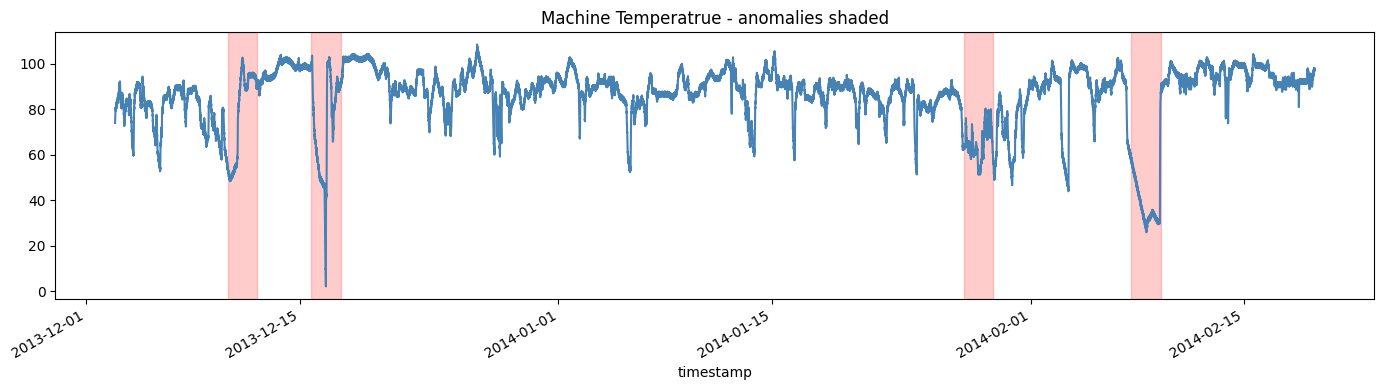

In [10]:
# plot time series with anomaly windows shaded
fig, ax = plt.subplots()
df['value'].plot(ax=ax, title='Machine Temperatrue - anomalies shaded', color='steelblue')

for window in labels[key]:
    ax.axvspan(window[0], window[1], color='red', alpha=0.2)

plt.tight_layout()
plt.show()     